# 1. IMDB(Internet Movie Database) 리뷰 감성 분류

**IMDB 리뷰 데이터에 대한 이해**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb

**IMDB 데이터 로드(IMDB 데이터는 train tdata와 test data를 50:50 비율로 구분해서 제공)**

In [2]:
(X_train, y_train), (X_test, y_test) = imdb.load_data()

print('훈련용 리뷰 개수 : {}'.format(len(X_train)))
print('테스트용 리뷰 개수 : {}'.format(len(X_test)))
num_classes = len(set(y_train))
print('카테고리 : {}'.format(num_classes))


훈련용 리뷰 개수 : 25000
테스트용 리뷰 개수 : 25000
카테고리 : 2


**X_train[0]에는 토큰화와 정수 인코딩이라는 텍스트 전처리 끝난 상태(단어들의 등장 빈도에 따라서 인덱스 부여)**

In [3]:
print('첫번째 훈련용 리뷰 :',X_train[0])
print('첫번째 훈련용 리뷰의 레이블 :',y_train[0])

첫번째 훈련용 리뷰 : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
첫번째 훈련용 리뷰의 레이블 : 1


**리뷰의 길이 분포를 그래프로 시각화**

리뷰의 최대 길이 : 2494
리뷰의 평균 길이 : 238.71364


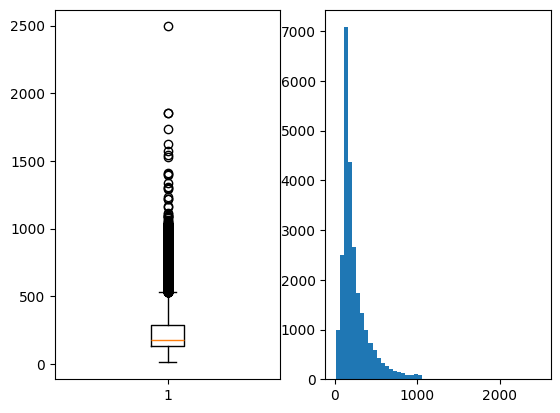

In [4]:
reviews_length = [len(review) for review in X_train]

print('리뷰의 최대 길이 : {}'.format(np.max(reviews_length)))
print('리뷰의 평균 길이 : {}'.format(np.mean(reviews_length)))

plt.subplot(1,2,1)
plt.boxplot(reviews_length)
plt.subplot(1,2,2)
plt.hist(reviews_length, bins=50)
plt.show()

**레이블에 대한 분포 확인**

In [5]:
unique_elements, counts_elements = np.unique(y_train, return_counts=True)
print("각 레이블에 대한 빈도수:")
print(np.asarray((unique_elements, counts_elements)))

각 레이블에 대한 빈도수:
[[    0     1]
 [12500 12500]]


**X_train에 있는 숫자들이 어떤 단어를 나타내는지 확인(0,1,2,3은 특별 토큰이라 정수 4부터가 빈도수 제일 높은 실제 영단어)**

In [6]:
word_to_index = imdb.get_word_index()
index_to_word = {}
for key, value in word_to_index.items():
    index_to_word[value+3] = key

**index_to_word로 실제단어 확인**

In [7]:
print('빈도수 상위 1등 단어 : {}'.format(index_to_word[4]))

빈도수 상위 1등 단어 : the


**X_train[0]의 단어가 정수로 바뀌기 전에 어떤 단어인지 확인**

In [8]:
for index, token in enumerate(("<pad>", "<sos>", "<unk>")):
  index_to_word[index] = token

print(' '.join([index_to_word[index] for index in X_train[0]]))

<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shoul

# 2. GRU(Gated Recurrent Unit,LSTM 단순 버전)으로 IMDB 리뷰 감성 분류하기

**단어 집합 크기 10000, 리뷰 최대 길이는 500으로 제한하여 패딩 진행**

In [9]:
import re
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Embedding
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

vocab_size = 10000
max_len = 500

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

**임베딩 벡터 차원은 100, 은닉상태크기는 128출력층에 로지스틱 회귀를 사용해야 하니 활성화 함수로 시그모이드, 손실 함수는 크로스 엔트로피**

In [10]:
embedding_dim = 100
hidden_units = 128

model = Sequential()
model.add(Embedding(vocab_size, embedding_dim))
model.add(GRU(hidden_units))
model.add(Dense(1, activation='sigmoid'))

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)
mc = ModelCheckpoint('GRU_model.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train, epochs=15, callbacks=[es, mc], batch_size=64, validation_split=0.2)


Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - acc: 0.6046 - loss: 0.6399
Epoch 1: val_acc improved from -inf to 0.79380, saving model to GRU_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 315s 998ms/step - acc: 0.6049 - loss: 0.6397 - val_acc: 0.7938 - val_loss: 0.6768
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 932ms/step - acc: 0.8206 - loss: 0.4070
Epoch 2: val_acc improved from 0.79380 to 0.85400, saving model to GRU_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 311s 994ms/step - acc: 0.8206 - loss: 0.4070 - val_acc: 0.8540 - val_loss: 0.3614
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - acc: 0.8611 - loss: 0.3325
Epoch 3: val_acc improved from 0.85400 to 0.86200, saving model to GRU_model.h5


313/313 ━━━━━━━━━━━━━━━━━━━━ 284s 907ms/step - acc: 0.8612 - loss: 0.3325 - val_acc: 0.8620 - val_loss: 0.3321
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - acc: 0.8892 - loss: 0.2762
Epoch 4: val_acc did not improve from 0.86200
313/313 ━━━━━━━━━━━━━━━━━━━━ 293s 935ms/step - acc: 0.8892 - loss: 0.2762 - val_acc: 0.7504 - val_loss: 0.6759
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - acc: 0.9004 - loss: 0.2518
Epoch 5: val_acc did not improve from 0.86200
313/313 ━━━━━━━━━━━━━━━━━━━━ 288s 918ms/step - acc: 0.9004 - loss: 0.2518 - val_acc: 0.8562 - val_loss: 0.3656
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - acc: 0.9241 - loss: 0.2036
Epoch 6: val_acc did not improve from 0.86200
313/313 ━━━━━━━━━━━━━━━━━━━━ 309s 988ms/step - acc: 0.9241 - loss: 0.2036 - val_acc: 0.8598 - val_loss: 0.3331
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9342 - loss: 0.1773
Epoch 7: val_acc did not improve from 0.86200
313/313 ━━━━━━━━━━━━━━━━━━━━ 358s 1s/step -